## I. Loading and Visualization of datasets


**Installing libraries**

In [38]:
%pip install -q matplotlib pandas torch torchvision

Note: you may need to restart the kernel to use updated packages.


### A. Occupancy Map

#### 1. creating / loading dataset 

In [39]:
import numpy as np
import torch

×32 maps, exactly 3 obstacles


We generate a 1000 binary matrices, 0 = free space, 1 = obstacle

We added walls equal to 1 

In [40]:
def make_maps(n=5000, size=64):
    maps = []
    for _ in range(n):
        m = np.zeros((size, size), dtype=np.float32)

        # Outer walls
        m[[0, -1], :] = 1
        m[:, [0, -1]] = 1

        # Random rectangular obstacles
        for _ in range(np.random.randint(2, 7)):
            w, h = np.random.randint(4, 15, size=2)
            x = np.random.randint(2, size - w - 2)
            y = np.random.randint(2, size - h - 2)
            m[y:y+h, x:x+w] = 1

        maps.append(m)

    return torch.tensor(np.array(maps)).unsqueeze(1)


In [41]:
X = make_maps()

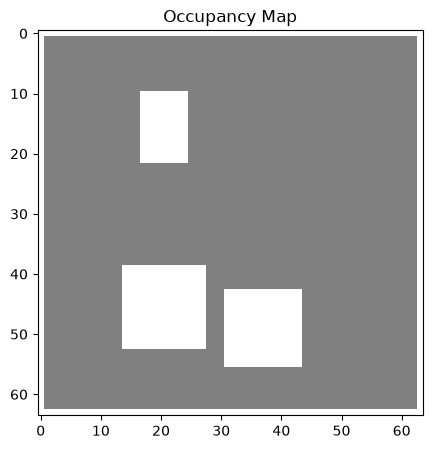

In [42]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 0 = free space, 1 = obstacle
cmap = ListedColormap(["grey", "white"])

plt.figure(figsize=(5, 5))
plt.imshow(X[0, 0], cmap=cmap)
plt.title("Occupancy Map")
plt.axis("on")
plt.show()

### B. BOP-format T-LESS dataset

In [44]:
from torch.utils.data import Dataset
from torchvision import transforms

In [45]:

class TLessDataset(Dataset):
    def __init__(self, root, objects=(1, 2, 3)):
        self.files = []

        for obj in objects:
            folder = Path(root) / f"{obj:06d}" / "rgb"
            self.files += [(f, obj) for f in folder.glob("*.png")]

        self.transform = transforms.Compose([
            transforms.Resize((64, 64)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        file, label = self.files[i]
        image = Image.open(file).convert("RGB")
        return self.transform(image), label

#### 2. Loading dataset into pytorch DataLoader

We start by loading data into TensorDataset function, which takes a data matrix and adds indexes to make it compatible with pytorch
Second, we load the indexed dataset into DataLoader, which shuffles our dataset and cuts into batches, ready to go into our model 

In [ ]:
from torch.utils.data import DataLoader, TensorDataset

dataset = TLessDataset(
    "tless/train_primesense",
    objects=(1, 2, 3)
)

loader = DataLoader(
    dataset,
    batch_size=32,
    shuffle=True
)

x, labels = next(iter(loader))

print(x.shape)       # [32, 3, 64, 64]
print(labels)

### II. Initializing VAE